# Task 3 — Data Visualization Dashboard

**Dataset:** synthetic retail sales data (2,000 orders, Jan 2024 – Aug 2025)
across 5 regions and 5 product categories.

This notebook builds every required chart type — **bar, line, pie,
histogram, and scatter** — using **Matplotlib** and **Seaborn**, each
customized with titles, axis labels, legends and a deliberate color
scheme, and closes with the key insights those charts reveal. A bonus
heatmap is included, and a separate bonus **interactive HTML dashboard**
(`dashboard.html`, built with Chart.js) lives in the project root.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

COLOR_CATEGORY = {
    "Electronics": "#4C72B0", "Clothing": "#DD8452", "Home & Kitchen": "#55A868",
    "Sports": "#C44E52", "Beauty": "#8172B2",
}
REGION_COLORS = sns.color_palette("crest", 5)
print("Libraries loaded.")

Libraries loaded.


## 1. Load the dataset

In [2]:
df = pd.read_csv("../data/sales_data.csv", parse_dates=["OrderDate"])
df["Month"] = df["OrderDate"].dt.to_period("M").dt.to_timestamp()
print(df.shape)
df.head()

(2000, 15)


    OrderID  OrderDate   Region  ... Rating PaymentMethod      Month
0  ORD10064 2024-01-01     East  ...    5.0   Credit Card 2024-01-01
1  ORD11117 2024-01-01     West  ...    4.1    Debit Card 2024-01-01
2  ORD10729 2024-01-01    North  ...    4.3    Debit Card 2024-01-01
3  ORD10806 2024-01-01  Central  ...    4.2   Credit Card 2024-01-01
4  ORD11505 2024-01-02     West  ...    4.8          Cash 2024-01-01

[5 rows x 15 columns]

## 2. Bar Chart — Total Sales by Product Category
Aggregates total sales per category to compare category performance at a glance.

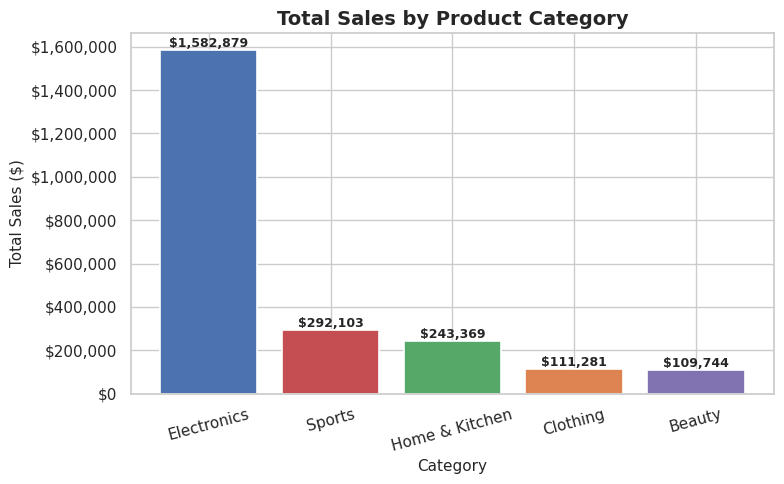

In [3]:
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cat_sales.index, cat_sales.values,
               color=[COLOR_CATEGORY[c] for c in cat_sales.index],
               edgecolor="white", linewidth=1.2)
ax.set_title("Total Sales by Product Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
for b in bars:
    ax.annotate(f"${b.get_height():,.0f}", (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 3. Line Chart — Monthly Sales Trend
Tracks total sales month over month to reveal seasonality and growth.

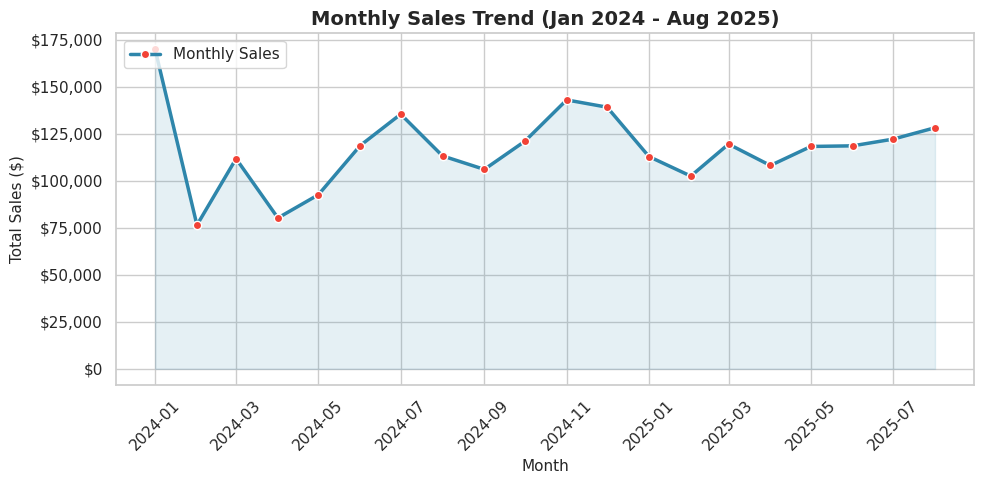

In [4]:
monthly = df.groupby("Month")["Sales"].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly["Month"], monthly["Sales"], marker="o", linewidth=2.5,
        color="#2E86AB", markerfacecolor="#F24236", markeredgecolor="white",
        markersize=6, label="Monthly Sales")
ax.fill_between(monthly["Month"], monthly["Sales"], alpha=0.12, color="#2E86AB")
ax.set_title("Monthly Sales Trend (Jan 2024 - Aug 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Pie Chart — Sales Share by Region
Shows each region's contribution to total sales as a share of the whole.

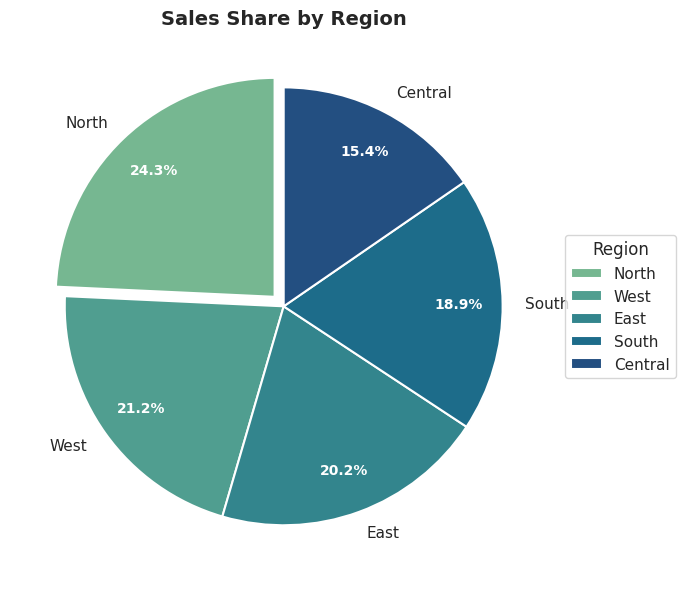

In [5]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    region_sales.values, labels=region_sales.index, autopct="%1.1f%%",
    colors=REGION_COLORS, startangle=90, pctdistance=0.8,
    explode=[0.06 if v == region_sales.max() else 0 for v in region_sales.values],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
plt.setp(autotexts, size=10, weight="bold", color="white")
ax.set_title("Sales Share by Region")
ax.legend(wedges, region_sales.index, title="Region", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.tight_layout()
plt.show()

## 5. Histogram — Distribution of Order Values
Shows how order values are spread out, with mean/median reference lines.

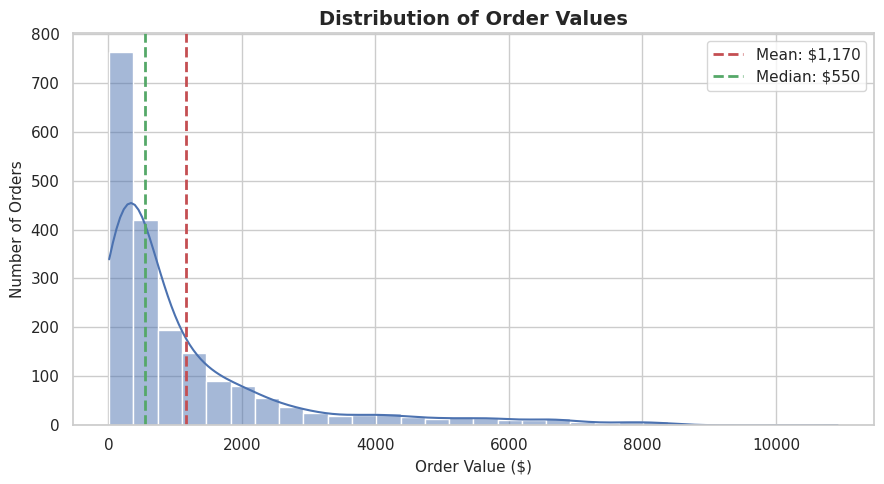

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["Sales"], bins=30, kde=True, color="#4C72B0", edgecolor="white", ax=ax)
mean_val, median_val = df["Sales"].mean(), df["Sales"].median()
ax.axvline(mean_val, color="#C44E52", linestyle="--", linewidth=2, label=f"Mean: ${mean_val:,.0f}")
ax.axvline(median_val, color="#55A868", linestyle="--", linewidth=2, label=f"Median: ${median_val:,.0f}")
ax.set_title("Distribution of Order Values")
ax.set_xlabel("Order Value ($)")
ax.set_ylabel("Number of Orders")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Scatter Plot — Quantity vs. Profit by Category
Explores whether larger orders (by quantity) translate into higher profit, split by category.

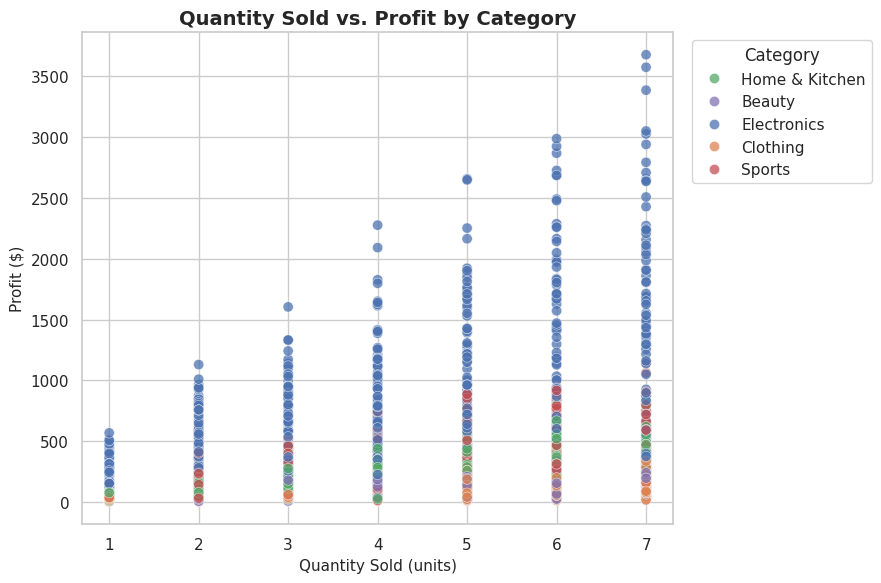

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x="Quantity", y="Profit", hue="Category",
                 palette=COLOR_CATEGORY, alpha=0.75, s=55,
                 edgecolor="white", linewidth=0.4, ax=ax)
ax.set_title("Quantity Sold vs. Profit by Category")
ax.set_xlabel("Quantity Sold (units)")
ax.set_ylabel("Profit ($)")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Bonus — Heatmap: Average Order Value by Region x Category
A quick way to spot the strongest region/category combinations.

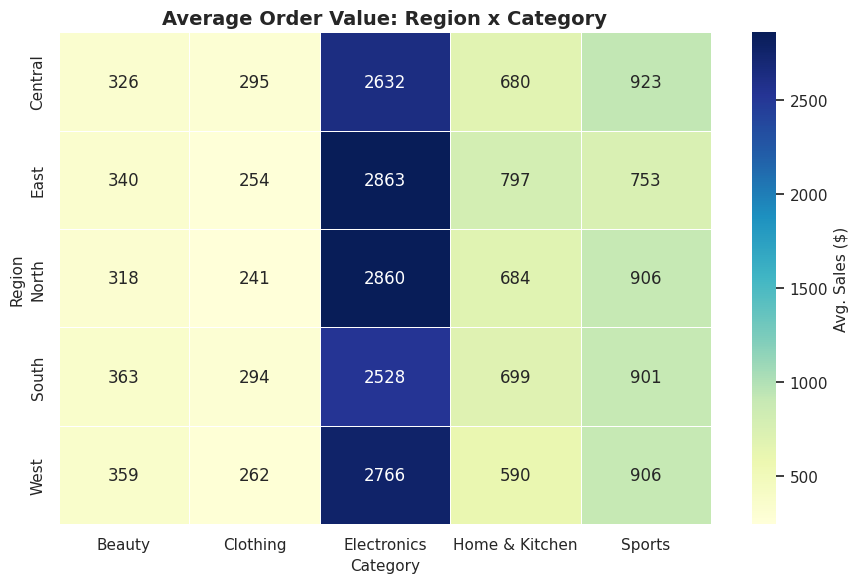

In [8]:
pivot = df.pivot_table(index="Region", columns="Category", values="Sales", aggfunc="mean")

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5,
            cbar_kws={"label": "Avg. Sales ($)"}, ax=ax)
ax.set_title("Average Order Value: Region x Category")
plt.tight_layout()
plt.show()

## Key Insights

In [9]:
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
top_cat = cat_sales.index[0]

monthly = df.groupby("Month")["Sales"].sum()
peak_month = monthly.idxmax()
avg_by_calendar_month = df.groupby(df["OrderDate"].dt.month)["Sales"].mean()
holiday_avg = avg_by_calendar_month.loc[[11, 12]].mean()
other_avg = avg_by_calendar_month.drop([11, 12]).mean()

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
top_region = region_sales.index[0]

mean_val, median_val = df["Sales"].mean(), df["Sales"].median()
corr = df["Quantity"].corr(df["Profit"])

pivot = df.pivot_table(index="Region", columns="Category", values="Sales", aggfunc="mean")
best_cell = pivot.stack().idxmax()

print("1.", f"'{top_cat}' is the top-performing category with ${cat_sales.iloc[0]:,.0f} in total sales.")
print("2.", f"{peak_month.strftime('%B %Y')} recorded the highest total sales; average order value in "
             f"Nov/Dec (${holiday_avg:,.0f}) runs {((holiday_avg/other_avg)-1):.0%} above the rest of the year.")
print("3.", f"The '{top_region}' region drives the largest share of sales "
             f"({region_sales.iloc[0]/region_sales.sum():.1%}).")
print("4.", f"Order values are right-skewed: mean (${mean_val:,.0f}) sits above median (${median_val:,.0f}).")
print("5.", f"Quantity vs. Profit correlation is weak (r = {corr:.2f}) - profit tracks price/margin more than order size.")
print("6.", f"Best avg. order value combo: {best_cell[0]} + {best_cell[1]} (${pivot.stack().max():,.0f} avg).")

1. 'Electronics' is the top-performing category with $1,582,879 in total sales.
2. January 2024 recorded the highest total sales; average order value in Nov/Dec ($1,365) runs 20% above the rest of the year.
3. The 'North' region drives the largest share of sales (24.3%).
4. Order values are right-skewed: mean ($1,170) sits above median ($550).
5. Quantity vs. Profit correlation is weak (r = 0.37) - profit tracks price/margin more than order size.
6. Best avg. order value combo: East + Electronics ($2,863 avg).


## Bonus — Interactive Dashboard
An interactive, filterable version of these charts (Region / Category / Year filters,
live KPIs) is available in **`dashboard.html`** at the project root — open it in any
browser, no server needed.